
<h1 align="center">PDDCNN Model</h3>
<h1 align="center">Training & Testing</h3>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

# Put here - the path to the Potato Leaf Disease (PLD) dataset and the path to the working folder
directory_root = '/content/drive/MyDrive/Precision Agriculture/PDDCNN'
dataset_root = '/content/drive/MyDrive/Precision Agriculture/PDDCNN/PLD_3_Classes_256'

Mounted at /content/drive


#**Imports**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

from keras import backend as K, regularizers
from keras.models import load_model, Sequential
from keras.layers import GlobalMaxPooling2D, AveragePooling2D, MaxPooling2D
from keras.layers import Flatten, Conv2D, Dense, Dropout, Activation
from keras.regularizers import l1, l2, l1_l2
from keras.optimizers import Adam, RMSprop
from sklearn.preprocessing import MultiLabelBinarizer
from keras.callbacks import History,CSVLogger, TensorBoard, ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator

In [2]:
# Setting all constant parameters
EPOCHS = 100                           # Number of ephocs
INIT_LR = 1e-3                         # Initial learning rate
BATCH_SIZE = 32                        # Batch size
""" Input Shape - Image Parameters """
WIDTH = 256
HEIGHT = 256
DEPTH = 3

#**Dataset**

The potato leaf dataset (PLD) was developed by capturing the images of potato leaves. The images are cropped and labelled with the help of plant pathologists. Theere are **three types** of potato leaf images:
- Early blight
- Late blight
- Healthy

The real-time dataset was collected in the form of videos and pictures taken by various capturing devices, such as mobile phone cameras, digital cameras and drones.

# Summary of the dataset

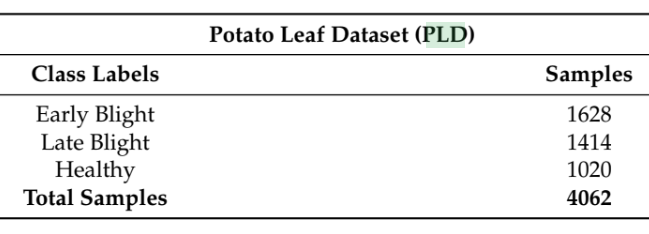

##Load Dataset

In [9]:
# Creating instances of the `ImageDataGenerator` class
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   rotation_range=25, width_shift_range=0.1,
                                   height_shift_range=0.1, shear_range=0.2,
                                   zoom_range=0.2,horizontal_flip=True,
                                   brightness_range=[0.5, 1.5], channel_shift_range=0.05,
                                   fill_mode="nearest")


# 2. Retrieving the iterator
training_set = train_datagen.flow_from_directory(dataset_root + '/Training',
                                                 target_size = (HEIGHT, WIDTH),
                                                 batch_size = BATCH_SIZE,
                                                 class_mode = 'categorical')


Found 3251 images belonging to 3 classes.


In [10]:
validation_datagen = ImageDataGenerator(rescale = 1./255)
validation_set = validation_datagen.flow_from_directory(dataset_root + '/Validation',
                                            target_size = (HEIGHT, WIDTH),
                                            batch_size = BATCH_SIZE,
                                            class_mode = 'categorical')


Found 416 images belonging to 3 classes.


In [11]:
test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory(dataset_root + '/Testing',
                                            target_size = (HEIGHT, WIDTH),
                                            batch_size = BATCH_SIZE,
                                            class_mode = 'categorical')

Found 405 images belonging to 3 classes.


Let's take a look at some of the images.

In [12]:
images, labels = next(training_set)

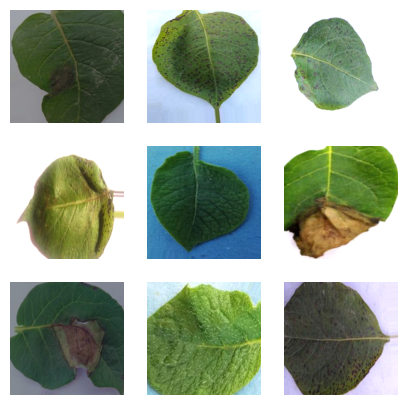

In [24]:
plt.figure(figsize=(5, 5))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.axis("off")

#**Model**

##Build Model

In [25]:
def model_builder(HEIGHT, WIDTH, DEPTH):
  classifier = Sequential()

  inputShape = (HEIGHT, WIDTH, DEPTH)
  chanDim = -1
  if K.image_data_format() == "channels_first":
      inputShape = (HEIGHT, WIDTH, DEPTH)
      chanDim = 1

  # Convolution
  classifier.add(Conv2D(64, (3, 3), input_shape = inputShape, padding = 'same'))
  classifier.add(Activation("relu"))
  classifier.add(MaxPooling2D())

  # Adding a second convolutional layer
  classifier.add(Conv2D(32, (3, 3), padding = 'same'))
  classifier.add(Activation("relu"))
  classifier.add(MaxPooling2D())

  # Adding a third convolutional layer
  classifier.add(Conv2D(16, (3, 3), padding = 'same'))
  classifier.add(Activation("relu"))
  classifier.add(MaxPooling2D())

  # Flattening
  classifier.add(Flatten())

  # Full connection
  classifier.add(Dense(units = 512))
  classifier.add(Activation("relu"))

  classifier.add(Dense(units = 256))
  classifier.add(Activation("relu"))

  classifier.add(Dense(units = 128))
  classifier.add(Activation("relu"))

  classifier.add(Dense(units = 3, activation = 'softmax'))

  # Print Summary
  classifier.summary()
  # Compile
  classifier.compile(optimizer = 'Adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])


claassifier = model_builder(HEIGHT, WIDTH, DEPTH)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 256, 256, 64)      1792      
                                                                 
 activation (Activation)     (None, 256, 256, 64)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 128, 128, 64)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      18464     
                                                                 
 activation_1 (Activation)   (None, 128, 128, 32)      0         
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 64, 64, 32)       0         
 2D)                                                    

##Training

In [ ]:
# Model is saved using ModelCheckpoint in a folder named [Weights]

ckpt_callback = ModelCheckpoint(filepath=os.path.join(directory_root + '/Weights', 'weights.{epoch:02d}.{accuracy:.4f}.hdf5'),
                                monitor = 'val_accuracy', save_best_only=True)
early = EarlyStopping(monitor='val_loss', min_delta=0, patience=20, verbose=1, mode='auto')

reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 10, verbose = 1, min_delta =0.00001)
csvlogger = CSVLogger(directory_root + '/History/training_csv.csv', append=True)


In [ ]:
# this is the directory where weights are saved
checkpoint_path = directory_root + '/Weights'

#
def checkpoint_function():
    '''
    thisfunction to loads weight file for resuming training from last epoch

    '''

    if not os.listdir(checkpoint_path):
        return

    files_int = list()
    for i in os.listdir(checkpoint_path):
        epoch = int(i.split('.')[1])
        files_int.append(epoch)
    max_value = max(files_int)

    for i in os.listdir(checkpoint_path):
        epoch = int(i.split('.')[1])
        if epoch > max_value:
            pass
        elif epoch < max_value:
            pass
        else:
            final_file = i
    return final_file, max_value

In [ ]:
checkpoint_path_file = checkpoint_function()

# This is where the training starts:
if checkpoint_path_file is not None:
     # Load model:
    checkpoint_path_file = checkpoint_function()[0]
    max_value = checkpoint_function()[1]

    classifier = load_model(os.path.join(checkpoint_path, checkpoint_path_file))
    print(max_value)
    history = classifier.fit(training_set,
                         epochs = EPOCHS,
                         initial_epoch = max_value,
                         validation_data = validation_set,
                         callbacks=[ckpt_callback,reduce_lr,csvlogger])
# if there is no checkpoint_path_file it means no file is saved and hence model will be trained from scratch
else:
     history = classifier.fit(training_set,
                         epochs = EPOCHS,
                         validation_data = validation_set,
                         callbacks=[ckpt_callback,reduce_lr,csvlogger])


Epoch 1/100
102/102 [==============================] - 773s 8s/step - loss: 1.0673 - accuracy: 0.4076 - val_loss: 0.9791 - val_accuracy: 0.5841 - lr: 0.0010
Epoch 2/100
102/102 [==============================] - 78s 763ms/step - loss: 0.8533 - accuracy: 0.6195 - val_loss: 0.7209 - val_accuracy: 0.7428 - lr: 0.0010
Epoch 3/100
102/102 [==============================] - 80s 779ms/step - loss: 0.6541 - accuracy: 0.7284 - val_loss: 0.5592 - val_accuracy: 0.8005 - lr: 0.0010
Epoch 4/100
102/102 [==============================] - 78s 765ms/step - loss: 0.5922 - accuracy: 0.7696 - val_loss: 0.5956 - val_accuracy: 0.7476 - lr: 0.0010
Epoch 5/100
102/102 [==============================] - 78s 766ms/step - loss: 0.4952 - accuracy: 0.8142 - val_loss: 0.4636 - val_accuracy: 0.8053 - lr: 0.0010
Epoch 6/100
102/102 [==============================] - 79s 770ms/step - loss: 0.4527 - accuracy: 0.8277 - val_loss: 0.5694 - val_accuracy: 0.8269 - lr: 0.0010
Epoch 7/100
102/102 [===========================

In [ ]:
# Saving the trained model
classifier.save(directory_root + '/PDDCNN_with_Augmentation.h5')
print('Model has been successfully saved!')

Model has been successfully saved!


##Evaluation

In [ ]:
def show_final_history(history):
    fig, ax = plt.subplots(1, 2, figsize = (15,5))
    ax[0].set_title('Model Loss on PLD Dataset')
    ax[0].plot(history.epoch, history.history["loss"], label="Training Loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")

    ax[1].set_title('Model Accuracy on PLD Dataset')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Training Accuracy")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")

    ax[0].grid()
    ax[1].grid()
    ax[0].legend()
    ax[1].legend()


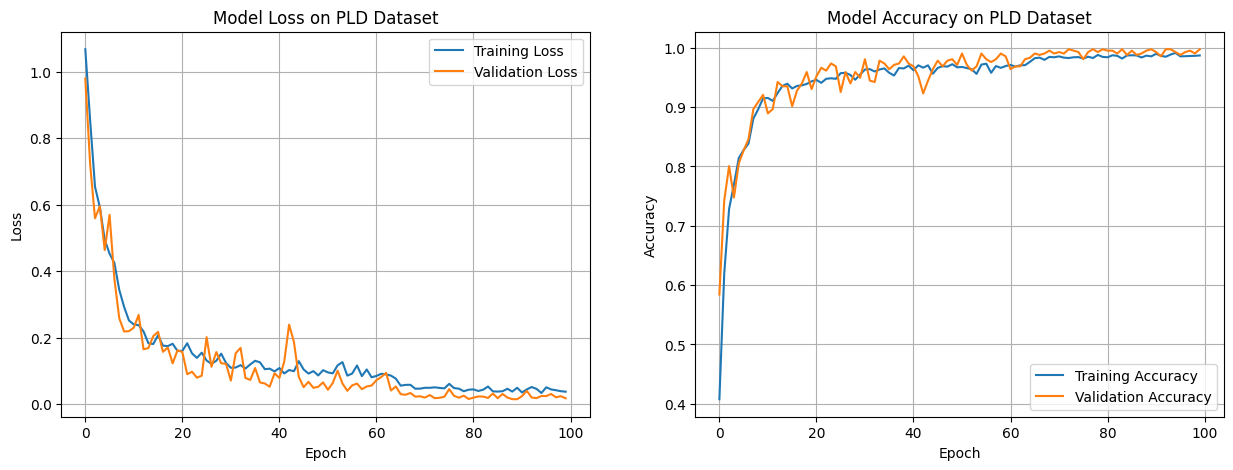

In [ ]:
show_final_history(history)

In [ ]:
a = classifier.evaluate(training_set)
b = classifier.evaluate(test_set)


print(a)
print(b)

13/13 [==============================] - 106s 9s/step - loss: 0.0881 - accuracy: 0.9778
[0.039843179285526276, 0.9849277138710022]
[0.08808135986328125, 0.9777777791023254]


In [ ]:
print("Test accuracy is {}%".format(100*b[1]))

Test accuracy is 97.77777791023254%
